In [85]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_val_score
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [86]:
x, y = make_moons(
    n_samples=200,
    noise=0.25,
    random_state=42
)

In [87]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

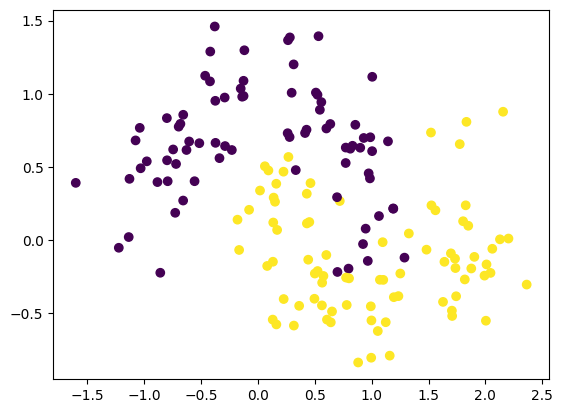

In [88]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)

dt : acurracy = 0.725


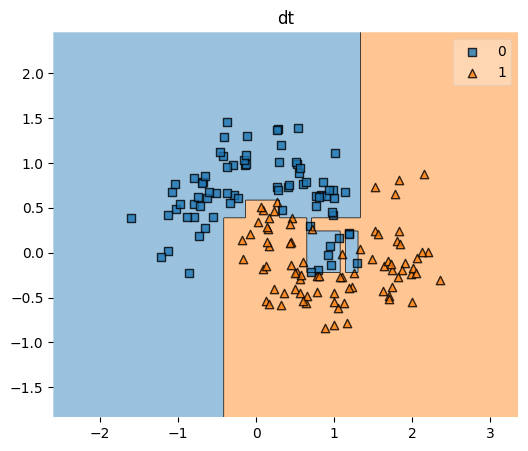

lr : acurracy = 0.85


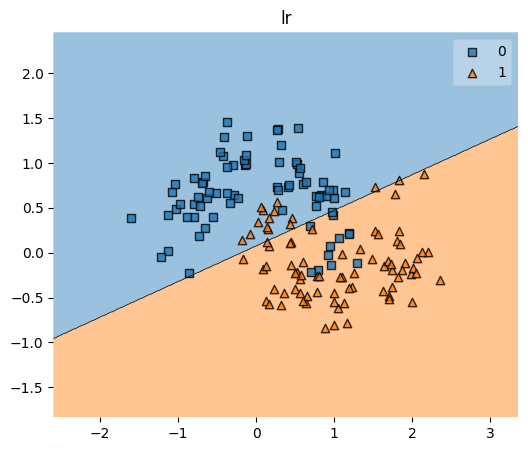

svc : acurracy = 0.85


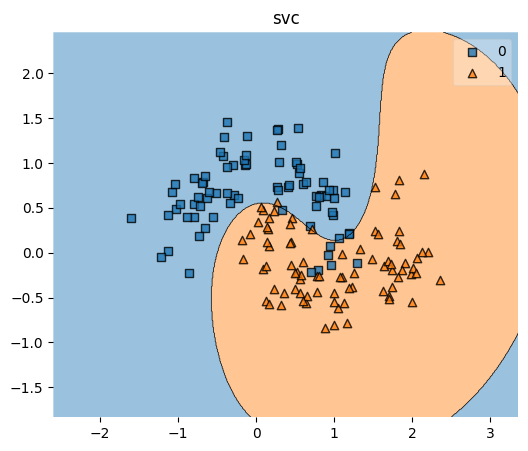

In [89]:
dt = DecisionTreeClassifier()
lr = LogisticRegression()
svc = SVC(probability=True)

estimators = [('dt',dt),('lr',lr),('svc',svc)]

for estimator in estimators:
    estimator[1].fit(x_train,y_train)
    cv = cross_val_score(estimator[1],x_test,y_test,scoring='accuracy',cv=5)
    print(f"{estimator[0]} : acurracy = {np.mean(cv)}")
    
    plt.figure(figsize=(6, 5))
    plot_decision_regions(x_train, y_train, clf=estimator[1])
    plt.title(estimator[0])
    plt.show()


Voting Ensemble : acurracy = 0.85


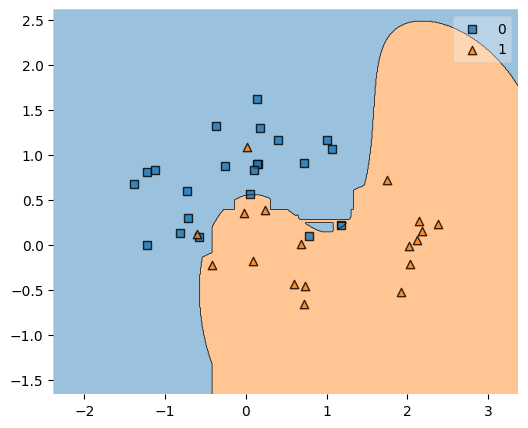

In [90]:
vc = VotingClassifier(estimators=estimators,voting='hard')
vc.fit(x_train,y_train)
cv = cross_val_score(vc,x_test,y_test,scoring='accuracy',cv=5)
print(f"Voting Ensemble : acurracy = {np.mean(cv)}") 
plt.figure(figsize=(6, 5))
plot_decision_regions(x_test, y_test, clf=vc)
plt.show()

clf1: acurracy = 0.825


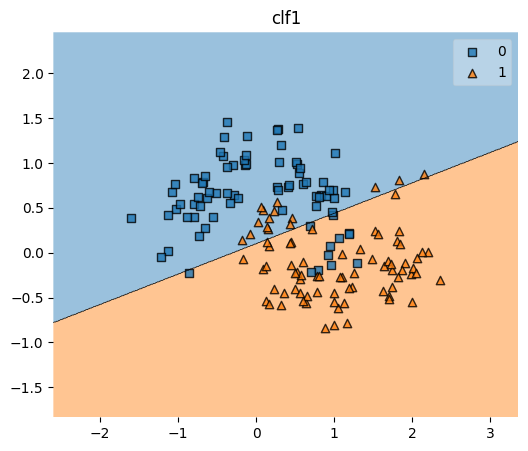

clf2: acurracy = 0.7


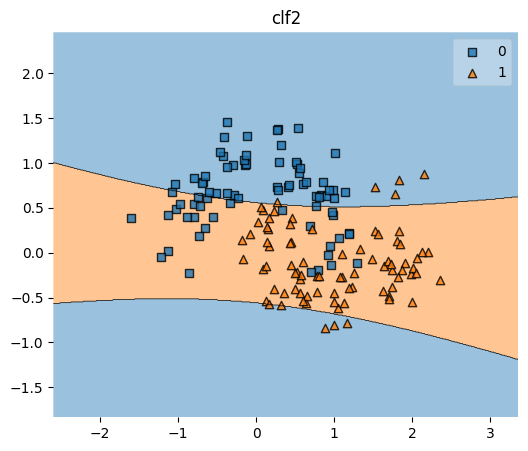

clf3: acurracy = 0.75


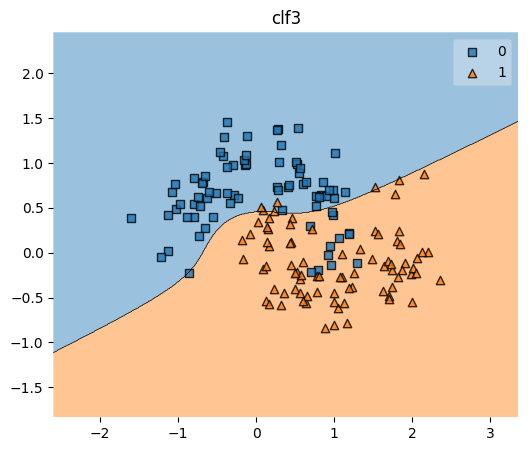

clf4: acurracy = 0.725


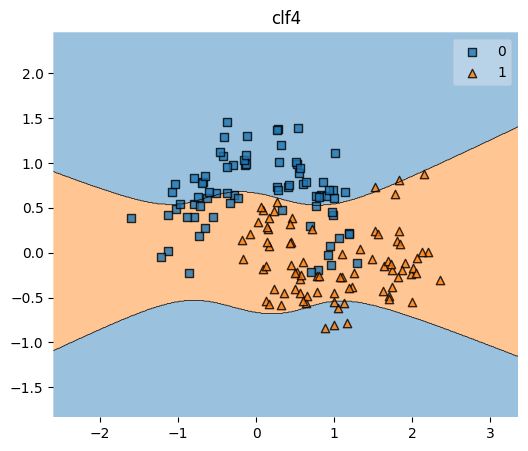

In [91]:
clf1 = SVC(kernel='poly',degree=1,probability=True)
clf2 = SVC(kernel='poly',degree=2,probability=True)
clf3 = SVC(kernel='poly',degree=3,probability=True)
clf4 = SVC(kernel='poly',degree=4,probability=True)

estimators_svc = [('clf1',clf1),('clf2',clf2),('clf3',clf3),('clf4',clf4)]
for est in estimators_svc:
    est[1].fit(x_train,y_train)
    cv = cross_val_score(est[1],x_test,y_test,scoring='accuracy',cv=5)
    print(f"{est[0]}: acurracy = {np.mean(cv)}") 
    plt.figure(figsize=(6, 5))
    plot_decision_regions(x_train,y_train, clf=est[1])
    plt.title(f"{est[0]}")
    plt.show()

In [92]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            for a in range(1,4):
                voting = VotingClassifier(estimators=estimators_svc,voting='soft',weights=[i,j,k,a])
                voting.fit(x_train,y_train)
                cv = cross_val_score(voting,x_test,y_test,scoring='accuracy',cv=5)
                print(f"[{i},{j},{k},{a}] acurracy = {np.mean(cv)}") 
                

[1,1,1,1] acurracy = 0.775
[1,1,1,2] acurracy = 0.7
[1,1,1,3] acurracy = 0.7
[1,1,2,1] acurracy = 0.725
[1,1,2,2] acurracy = 0.725
[1,1,2,3] acurracy = 0.7
[1,1,3,1] acurracy = 0.725
[1,1,3,2] acurracy = 0.725
[1,1,3,3] acurracy = 0.725
[1,2,1,1] acurracy = 0.725
[1,2,1,2] acurracy = 0.725
[1,2,1,3] acurracy = 0.675
[1,2,2,1] acurracy = 0.7
[1,2,2,2] acurracy = 0.725
[1,2,2,3] acurracy = 0.7
[1,2,3,1] acurracy = 0.725
[1,2,3,2] acurracy = 0.7
[1,2,3,3] acurracy = 0.7
[1,3,1,1] acurracy = 0.725
[1,3,1,2] acurracy = 0.7
[1,3,1,3] acurracy = 0.725
[1,3,2,1] acurracy = 0.75
[1,3,2,2] acurracy = 0.7
[1,3,2,3] acurracy = 0.7
[1,3,3,1] acurracy = 0.7
[1,3,3,2] acurracy = 0.7
[1,3,3,3] acurracy = 0.675
[2,1,1,1] acurracy = 0.825
[2,1,1,2] acurracy = 0.8
[2,1,1,3] acurracy = 0.75
[2,1,2,1] acurracy = 0.825
[2,1,2,2] acurracy = 0.825
[2,1,2,3] acurracy = 0.8
[2,1,3,1] acurracy = 0.8
[2,1,3,2] acurracy = 0.725
[2,1,3,3] acurracy = 0.725
[2,2,1,1] acurracy = 0.825
[2,2,1,2] acurracy = 0.825
[2,2,1